# DeBERTa-v3-large + LoRA — Maximum Optimization (Single Evidence)

**Model**: `microsoft/deberta-v3-large`  
**Task**: 3-class NLI — `SUPPORTS` / `REFUTES` / `NOT ENOUGH INFO`  
**Input**: one claim + one evidence sentence per example  

## Files needed in the same folder as this notebook
```
final_cleaned_nli_dataset.jsonl   <- your original dataset
claim_extractor.py                <- for the inference pipeline
```

## Optimizations included
| Technique | Why it helps |
|---|---|
| LoRA r=16 | trains only ~3M params, faster + less overfitting |
| R-Drop regularization | forces consistency between two dropout forward passes |
| FGM adversarial training | perturbs embeddings to build robustness |
| EMA weights | exponential moving average gives smoother generalization |
| Dynamic padding | batches by length, much faster training |
| Cosine schedule + long warmup | stable training curve |
| Label smoothing 0.1 | prevents overconfidence |
| Seed ensemble | averages 3 seeds at inference for +1-2% F1 |
| MAX_LEN 256 | single evidence sentences are short, 256 is enough |

## Step 1 - Install dependencies

In [1]:
%pip install transformers>=4.40.0 -q
%pip install peft>=0.10.0 -q
%pip install accelerate>=0.29.0 -q
%pip install scikit-learn -q
%pip install matplotlib -q
%pip install seaborn -q
%pip install jsonlines -q
%pip install sentencepiece -q
%pip install protobuf -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgr

In [2]:
%pip uninstall -y tensorflow tensorflow-text tensorflow-hub tf-keras

Note: you may need to restart the kernel to use updated packages.


## Step 2 - Imports

In [3]:
import os
import json
import random
import jsonlines
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import google.protobuf
print(google.protobuf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

3.20.3
Device : cuda
GPU    : Quadro RTX 5000
VRAM   : 16.7 GB


## Step 3 - Configuration

In [ ]:
# Dataset
DATASET_FILE = "final_cleaned_nli_dataset.jsonl"
OUTPUT_DIR   = "deberta_single_evidence_v3"

# Set to True when you have a held-out test split ready.
# Until then test evaluation is skipped automatically.
HAS_TEST_SET = True

# Model
MODEL_NAME = "microsoft/deberta-v3-large"

# Labels
LABEL2ID   = {"SUPPORTS": 0, "REFUTES": 1, "NOT ENOUGH INFO": 2}
ID2LABEL   = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3

# Tokenization — 256 is enough for single evidence sentences
MAX_LEN = 256

# LoRA
LORA_R              = 32
LORA_ALPHA          = 64
LORA_DROPOUT        = 0.1
LORA_TARGET_MODULES = ["query_proj", "value_proj"]

# Training
BATCH_SIZE      = 16
GRAD_ACCUM      = 2
EPOCHS          = 4 
LR              = 5e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
LABEL_SMOOTHING = 0.05
MAX_GRAD_NORM   = 1.0

# Regularization
RDROP_ALPHA = 0.5
FGM_EPSILON = 0.5
EMA_DECAY   = 0.999
USE_EMA     = True

# Ensemble
USE_ENSEMBLE   = True
ENSEMBLE_SEEDS = [42, 123, 777]

# Dataset split
TRAIN_RATIO = 0.94
VAL_RATIO   = 0.06
# remaining 0.06 -> test (only used when HAS_TEST_SET=True)

#Class weights
#CLASS_WEIGHTS = torch.tensor([1.0, 2.538, 2.514]).to(DEVICE)
PATIENCE = 3
USE_AMP  = torch.cuda.is_available()

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded.")
print(f"HAS_TEST_SET : {HAS_TEST_SET}")

Configuration loaded.
HAS_TEST_SET : False


In [ ]:
# ── Load dev test set ────────────────────────────────────────
import jsonlines

test_data = []
with jsonlines.open("dev_final_cleaned_testset.jsonl") as reader:
    for obj in reader:
        test_data.append(obj)

print(f"Test set loaded: {len(test_data):,} examples")
from collections import Counter
print("Labels:", dict(Counter(r["label"] for r in test_data)))

test_loader = DataLoader(
    FeverDataset(test_data),
    batch_size=64,        # larger than training batch — no gradients, fits easily
    shuffle=False,        # must stay ordered for label alignment
    collate_fn=collator,
    num_workers=2,
    pin_memory=True
)
print(f"Test loader: {len(test_loader):,} batches")

## Step 4 - Load and prepare dataset

Loads your original `final_cleaned_nli_dataset.jsonl` directly.
Each record already has exactly one evidence sentence — no aggregation needed.
We clean, balance, and split here.

In [5]:
# Load — data is already clean and shuffled
raw_records = []
with jsonlines.open(DATASET_FILE) as reader:
    for obj in reader:
        raw_records.append(obj)

print(f"Records loaded: {len(raw_records):,}")

# Show distribution
counts = Counter(r["label"] for r in raw_records)
print("\nLabel distribution:")
for lbl, cnt in sorted(counts.items()):
    print(f"  {lbl:20s}: {cnt:,}  ({cnt/len(raw_records)*100:.1f}%)")

# Split into train and val only — no test set
n       = len(raw_records)
n_train = int(n * TRAIN_RATIO)

train_data = raw_records[:n_train]
val_data   = raw_records[n_train:]

print(f"\nSplit:")
print(f"  Train : {len(train_data):,}")
print(f"  Val   : {len(val_data):,}")

# Compute class weights from training data
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_array = np.array([LABEL2ID[r["label"]] for r in train_data])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_labels_array
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f"\nClass weights:")
for i, w in enumerate(class_weights):
    print(f"  {ID2LABEL[i]:20s}: {w:.4f}")

# Sample
sample = train_data[0]
print(f"\nSample record:")
print(f"  claim    : {sample['claim']}")
print(f"  evidence : {sample['evidence']}")
print(f"  label    : {sample['label']}")

Records loaded: 157,089

Label distribution:
  NOT ENOUGH INFO     : 34,870  (22.2%)
  REFUTES             : 34,543  (22.0%)
  SUPPORTS            : 87,676  (55.8%)

Split:
  Train : 147,663
  Val   : 9,426

Class weights:
  SUPPORTS            : 0.5969
  REFUTES             : 1.5176
  NOT ENOUGH INFO     : 1.5023

Sample record:
  claim    : Gerald Ford was a politician.
  evidence : As President , Ford signed the Helsinki Accords , marking a move toward détente in the Cold War .
  label    : SUPPORTS


## Step 5 - Tokenizer and Dataset

In [6]:
%pip install protobuf==3.20.3 -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

/home/ai-ws2/.local/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer loaded: microsoft/deberta-v3-large


In [8]:
class FeverDataset(Dataset):
    """
    Each record has exactly one evidence sentence.
    Returns raw strings — tokenization happens in the collator.

    DeBERTa input format:
        [CLS] claim [SEP] evidence [SEP]
    """

    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        return {
            "claim":    rec["claim"].strip(),
            "evidence": rec["evidence"].strip(),
            "label":    LABEL2ID[rec["label"]],
        }


class DynamicPaddingCollator:
    """
    Tokenizes each batch and pads only to the longest sequence
    in that batch — much faster than always padding to MAX_LEN.
    """

    def __init__(self, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __call__(self, batch):
        claims    = [item["claim"]    for item in batch]
        evidences = [item["evidence"] for item in batch]
        labels    = [item["label"]    for item in batch]
        encoding  = self.tokenizer(
            claims, evidences,
            max_length=self.max_len,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        encoding["labels"] = torch.tensor(labels, dtype=torch.long)
        return encoding


collator     = DynamicPaddingCollator(tokenizer, MAX_LEN)
train_loader = DataLoader(FeverDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collator, num_workers=2, pin_memory=True)
val_loader   = DataLoader(FeverDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=True)

if HAS_TEST_SET and test_data:
    test_loader = DataLoader(FeverDataset(test_data), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=True)
    print(f"Test loader  : {len(test_loader):,} batches")
else:
    test_loader = None
    print("Test loader  : skipped (HAS_TEST_SET=False)")

print(f"Train loader : {len(train_loader):,} batches")
print(f"Val loader   : {len(val_loader):,} batches")

Test loader  : skipped (HAS_TEST_SET=False)
Train loader : 9,229 batches
Val loader   : 590 batches


## Step 6 - EMA

In [9]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.model  = model
        self.decay  = decay
        self.shadow = {}
        self.backup = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad and "modules_to_save" not in name:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.shadow[name] = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.backup:
                param.data = self.backup[name]
        self.backup = {}

    def save_shadow(self, model, save_path):
        """
        Saves EMA shadow weights to disk without disturbing real weights.
        Uses apply_shadow → save → restore pattern.
        """
        self.apply_shadow()
        model.save_pretrained(save_path)
        self.restore()    


print("EMA ready.")

EMA ready.


## Step 7 - FGM

In [10]:
class FGM:
    def __init__(self, model, epsilon=1.0, emb_name="word_embeddings"):
        self.model    = model
        self.epsilon  = epsilon
        self.emb_name = emb_name
        self.backup   = {}

    def attack(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and self.emb_name in name:
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    param.data.add_(self.epsilon * param.grad / norm)

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.backup:
                param.data = self.backup[name]
        self.backup = {}


print("FGM ready.")

FGM ready.


## Step 8 - R-Drop loss

In [11]:
def rdrop_loss(logits1, logits2, labels, alpha=0.7, label_smoothing=0.1, weight=None):
    ce_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing, weight=weight)
    ce    = (ce_fn(logits1, labels) + ce_fn(logits2, labels)) / 2
    p1    = F.softmax(logits1, dim=-1)
    p2    = F.softmax(logits2, dim=-1)
    kl    = (F.kl_div(F.log_softmax(logits1, dim=-1), p2, reduction="batchmean") + F.kl_div(F.log_softmax(logits2, dim=-1), p1, reduction="batchmean")) / 2
    return ce + alpha * kl

print("R-Drop loss ready.")

R-Drop loss ready.


## Step 9 - Build model with LoRA

In [12]:
def build_model():
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
        bias="none",
        inference_mode=False,
        modules_to_save=["classifier", "pooler"],
    )
    model = get_peft_model(base, lora_config)
    model.enable_input_require_grads()
    model.base_model.model.gradient_checkpointing_enable()
    model = model.to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total: {total/1e6:.1f}M  |  Trainable (LoRA): {trainable/1e6:.2f}M  ({100*trainable/total:.2f}%)")
    return model


print("Building model...")
model = build_model()

Building model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Total: 439.3M  |  Trainable (LoRA): 4.20M  (0.96%)


## Step 10 - Optimizer and scheduler

In [13]:
def build_optimizer_scheduler(model, train_loader):
    optimizer    = AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-6)
    total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    print(f"  Total steps: {total_steps:,}  |  Warmup: {warmup_steps:,}")
    return optimizer, scheduler


optimizer, scheduler = build_optimizer_scheduler(model, train_loader)
scaler = GradScaler() if USE_AMP else None
ema    = EMA(model, decay=EMA_DECAY) if USE_EMA else None
fgm    = FGM(model, epsilon=FGM_EPSILON) if FGM_EPSILON > 0 else None

print(f"EMA: {USE_EMA}  |  FGM: {FGM_EPSILON > 0}  |  R-Drop alpha: {RDROP_ALPHA}  |  AMP: {USE_AMP}")

  Total steps: 18,456  |  Warmup: 1,845
EMA: True  |  FGM: True  |  R-Drop alpha: 0.5  |  AMP: True


/tmp/ipykernel_2500012/4027818278.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if USE_AMP else None


## Step 11 - Training and evaluation functions

In [14]:
def train_epoch(model, loader, optimizer, scheduler, scaler, ema, fgm, grad_accum):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)

        kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids

        # R-Drop: two forward passes with different dropout masks
        if USE_AMP:
            with autocast():
                out1 = model(**kwargs)
                out2 = model(**kwargs)
                loss = rdrop_loss(out1.logits, out2.logits, labels, alpha=RDROP_ALPHA, label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor) / grad_accum
            scaler.scale(loss).backward()
        else:
            out1 = model(**kwargs)
            out2 = model(**kwargs)
            loss = rdrop_loss(out1.logits, out2.logits, labels, alpha=RDROP_ALPHA, label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor) / grad_accum
            loss.backward()

        total_loss += loss.item() * grad_accum

        # FGM: adversarial pass on perturbed embeddings
        if fgm is not None:
            fgm.attack()
            if USE_AMP:
                with autocast():
                    adv_loss = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor)(model(**kwargs).logits, labels) / grad_accum
                scaler.scale(adv_loss).backward()
            else:
                adv_loss = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor)(model(**kwargs).logits, labels) / grad_accum
                adv_loss.backward()
            fgm.restore()

        # Optimizer step every grad_accum batches
        if (step + 1) % grad_accum == 0:
            if USE_AMP:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], MAX_GRAD_NORM)
            if USE_AMP:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            if ema is not None:
                ema.update()

        if (step + 1) % 200 == 0:
            print(f"  step {step+1:5d}/{len(loader)}  loss={total_loss/(step+1):.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, ema=None):
    if ema is not None:
        ema.apply_shadow()
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    ce_fn = nn.CrossEntropyLoss()

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        token_type_ids = batch.get("token_type_ids")
        kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids.to(DEVICE)
        outputs = model(**kwargs)
        total_loss += ce_fn(outputs.logits, labels).item()
        all_preds.extend(torch.argmax(outputs.logits, dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    if ema is not None:
        ema.restore()

    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro"), accuracy_score(all_labels, all_preds), all_preds, all_labels

## Step 12 - Training loop

In [15]:
from tqdm.auto import tqdm

def train_single_model(seed, train_data, val_data, model_save_path):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    shuffled = train_data.copy()
    random.shuffle(shuffled)
    t_loader = DataLoader(FeverDataset(shuffled),  batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collator, num_workers=2, pin_memory=True)
    v_loader = DataLoader(FeverDataset(val_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=True)
    m        = build_model()
    opt, sch = build_optimizer_scheduler(m, t_loader)
    sc       = GradScaler() if USE_AMP else None
    e        = EMA(m, decay=EMA_DECAY) if USE_EMA else None
    f        = FGM(m, epsilon=FGM_EPSILON) if FGM_EPSILON > 0 else None
    history        = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
    best_val_f1    = 0.0
    patience_count = 0

    # Derive EMA save path from real weights path — saved separately
    ema_save_path = model_save_path + "_ema"

    for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
        print(f"  Epoch {epoch}/{EPOCHS}")
        train_loss = train_epoch(m, t_loader, opt, sch, sc, e, f, GRAD_ACCUM)
        val_loss, val_f1, val_acc, _, _ = evaluate(m, v_loader, e)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)
        print(f"    train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_F1={val_f1:.4f}  val_acc={val_acc:.4f}")
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_count = 0

            # Save real weights checkpoint at best val F1
            m.save_pretrained(model_save_path)
            tokenizer.save_pretrained(model_save_path)
            print(f"    Real weights saved (F1={best_val_f1:.4f})")

            # Save EMA shadow weights separately — real weights completely undisturbed
            # Uses save_shadow: apply_shadow → save → restore internally
            if e is not None:
                e.save_shadow(m, ema_save_path)
                tokenizer.save_pretrained(ema_save_path)
                print(f"    EMA shadow weights saved  path={ema_save_path}")

        else:
            patience_count += 1
            print(f"    No improvement. Patience {patience_count}/{PATIENCE}")
            if patience_count >= PATIENCE:
                print("    Early stopping triggered.")
                break

    # Save final weights after all epochs complete for both real and EMA
    # Useful for comparison and ablation — quantifies EMA contribution
    final_real_path = model_save_path + "_final_real"
    m.save_pretrained(final_real_path)
    tokenizer.save_pretrained(final_real_path)
    print(f"    Final real weights saved  path={final_real_path}")

    if e is not None:
        final_ema_path = model_save_path + "_final_ema"
        e.save_shadow(m, final_ema_path)
        tokenizer.save_pretrained(final_ema_path)
        print(f"    Final EMA shadow weights saved  path={final_ema_path}")

    return best_val_f1, history, ema_save_path


seeds_to_run  = ENSEMBLE_SEEDS if USE_ENSEMBLE else [SEED]
adapter_paths     = []  # real weights paths
ema_adapter_paths = []  # EMA shadow weights paths — use these for inference
all_histories     = []

for i, seed in enumerate(tqdm(seeds_to_run, desc="Models")):
    print(f"\n{'='*60}")
    print(f"TRAINING MODEL {i+1}/{len(seeds_to_run)}  (seed={seed})")
    print(f"{'='*60}")
    save_path = os.path.join(OUTPUT_DIR, f"adapter_seed_{seed}")
    best_f1, history, ema_path = train_single_model(seed, train_data, val_data, save_path)
    adapter_paths.append(save_path)
    ema_adapter_paths.append(ema_path)  # track EMA paths for inference loading
    all_histories.append(history)
    print(f"Model {i+1} done. Best val F1: {best_f1:.4f}")

print("\nAll models trained:")
print("\nReal weights paths:")
for p in adapter_paths:
    print(f"  {p}")
print("\nEMA shadow weights paths (use for inference):")
for p in ema_adapter_paths:
    print(f"  {p}")

Models:   0%|          | 0/3 [00:00<?, ?it/s]


TRAINING MODEL 1/3  (seed=42)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Total: 439.3M  |  Trainable (LoRA): 4.20M  (0.96%)
  Total steps: 18,456  |  Warmup: 1,845


/tmp/ipykernel_2500012/1516250903.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  sc       = GradScaler() if USE_AMP else None


...

  step   200/9229  loss=0.2645  lr=8.57e-06
  step   400/9229  loss=0.2661  lr=8.22e-06
  step   600/9229  loss=0.2667  lr=7.87e-06
  step   800/9229  loss=0.2663  lr=7.53e-06
  step  1000/9229  loss=0.2695  lr=7.19e-06
  step  1200/9229  loss=0.2673  lr=6.86e-06
  step  1400/9229  loss=0.2659  lr=6.54e-06
  step  1600/9229  loss=0.2655  lr=6.23e-06
  step  1800/9229  loss=0.2663  lr=5.92e-06
  step  2000/9229  loss=0.2662  lr=5.62e-06
  step  2200/9229  loss=0.2655  lr=5.32e-06
  step  2400/9229  loss=0.2664  lr=5.03e-06
  step  2600/9229  loss=0.2673  lr=4.75e-06
  step  2800/9229  loss=0.2672  lr=4.48e-06
  step  3000/9229  loss=0.2671  lr=4.21e-06
  step  3200/9229  loss=0.2679  lr=3.95e-06
  step  3400/9229  loss=0.2683  lr=3.70e-06
  step  3600/9229  loss=0.2686  lr=3.46e-06
  step  3800/9229  loss=0.2687  lr=3.22e-06
  step  4000/9229  loss=0.2690  lr=2.99e-06
  step  4200/9229  loss=0.2691  lr=2.77e-06
  step  4400/9229  loss=0.2695  lr=2.56e-06
  step  4600/9229  loss=0.2694  

/home/ai-ws2/.local/lib/python3.10/site-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /microsoft/deberta-v3-large/resolve/main/config.json (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7821987c2920>: Failed to establish a new connection: [Errno -3] Temporary failure in name resolution'))"), '(Request ID: 8136265a-92f8-4626-a6fa-df9ab17a85c7)') - silently ignoring the lookup for the file config.json in microsoft/deberta-v3-large.
  warnings.warn(
/home/ai-ws2/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in microsoft/deberta-v3-large - will assume that the vocabulary was not modified.
  warnings.warn(


    Real weights saved (F1=0.9632)


/home/ai-ws2/.local/lib/python3.10/site-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /microsoft/deberta-v3-large/resolve/main/config.json (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x78219679d1b0>: Failed to establish a new connection: [Errno -3] Temporary failure in name resolution'))"), '(Request ID: 99aec7cb-1d36-4739-8388-21bcad21f08c)') - silently ignoring the lookup for the file config.json in microsoft/deberta-v3-large.
  warnings.warn(


    EMA shadow weights saved  path=deberta_single_evidence_v3/adapter_seed_777_ema
    Final real weights saved  path=deberta_single_evidence_v3/adapter_seed_777_final_real
    Final EMA shadow weights saved  path=deberta_single_evidence_v3/adapter_seed_777_final_ema
Model 3 done. Best val F1: 0.9632

All models trained:

Real weights paths:
  deberta_single_evidence_v3/adapter_seed_42
  deberta_single_evidence_v3/adapter_seed_123
  deberta_single_evidence_v3/adapter_seed_777

EMA shadow weights paths (use for inference):
  deberta_single_evidence_v3/adapter_seed_42_ema
  deberta_single_evidence_v3/adapter_seed_123_ema
  deberta_single_evidence_v3/adapter_seed_777_ema


In [23]:
# ── Ensemble Evaluation on Validation Set ─────────────────────────
# Loads EMA shadow weight checkpoints (best val F1 checkpoints)
# Averages logits across all 3 seeds → computes final ensemble F1

print("Loading EMA ensemble models...")
ensemble_models = []

for path in ema_adapter_paths:
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )
    m = PeftModel.from_pretrained(base, path)
    m = m.to(DEVICE)
    m.eval()
    ensemble_models.append(m)
    print(f"  Loaded: {path}")

print(f"\nRunning ensemble inference on validation set ({len(val_data):,} examples)...")

all_labels = []
all_logits = []  # accumulate per-batch averaged logits

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        token_type_ids = batch.get("token_type_ids")
        kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids.to(DEVICE)

        # Average logits across all 3 models
        batch_logits = torch.stack(
            [m(**kwargs).logits for m in ensemble_models]
        ).mean(0)

        all_logits.append(batch_logits.cpu())
        all_labels.extend(labels.cpu().numpy())

# Compute final predictions from averaged logits
all_logits  = torch.cat(all_logits, dim=0)
all_preds   = torch.argmax(all_logits, dim=-1).numpy()
all_labels  = np.array(all_labels)

ensemble_f1  = f1_score(all_labels, all_preds, average="macro")
ensemble_acc = accuracy_score(all_labels, all_preds)

print(f"\n{'='*50}")
print(f"ENSEMBLE RESULTS (EMA weights, val set)")
print(f"{'='*50}")
print(f"  Macro F1  : {ensemble_f1:.4f}")
print(f"  Accuracy  : {ensemble_acc:.4f}")
print(f"\nPer-seed best val F1 (individual):")
for seed, path in zip(seeds_to_run, ema_adapter_paths):
    print(f"  seed={seed}  →  {path}")

print(f"\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]
))

Loading EMA ensemble models...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Loaded: deberta_single_evidence_v3/adapter_seed_42_ema


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Loaded: deberta_single_evidence_v3/adapter_seed_123_ema


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Loaded: deberta_single_evidence_v3/adapter_seed_777_ema

Running ensemble inference on validation set (9,426 examples)...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



ENSEMBLE RESULTS (EMA weights, val set)
  Macro F1  : 0.9650
  Accuracy  : 0.9683

Per-seed best val F1 (individual):
  seed=42  →  deberta_single_evidence_v3/adapter_seed_42_ema
  seed=123  →  deberta_single_evidence_v3/adapter_seed_123_ema
  seed=777  →  deberta_single_evidence_v3/adapter_seed_777_ema

Classification Report:
                 precision    recall  f1-score   support

       SUPPORTS       0.98      0.97      0.98      5210
        REFUTES       0.93      0.96      0.94      2110
NOT ENOUGH INFO       0.99      0.97      0.98      2106

       accuracy                           0.97      9426
      macro avg       0.96      0.97      0.96      9426
   weighted avg       0.97      0.97      0.97      9426



In [24]:
# Verify EMA adapter saves contain classifier weights
import os

for path in ema_adapter_paths:
    files = os.listdir(path)
    size  = {f: os.path.getsize(os.path.join(path, f)) / 1e6 for f in files}
    print(f"\n{path}:")
    for f, s in sorted(size.items()):
        print(f"  {f}  ({s:.2f} MB)")


deberta_single_evidence_v3/adapter_seed_42_ema:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (16.81 MB)
  added_tokens.json  (0.00 MB)
  special_tokens_map.json  (0.00 MB)
  spm.model  (2.46 MB)
  tokenizer.json  (8.66 MB)
  tokenizer_config.json  (0.00 MB)

deberta_single_evidence_v3/adapter_seed_123_ema:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (16.81 MB)
  added_tokens.json  (0.00 MB)
  special_tokens_map.json  (0.00 MB)
  spm.model  (2.46 MB)
  tokenizer.json  (8.66 MB)
  tokenizer_config.json  (0.00 MB)

deberta_single_evidence_v3/adapter_seed_777_ema:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (16.81 MB)
  added_tokens.json  (0.00 MB)
  special_tokens_map.json  (0.00 MB)
  spm.model  (2.46 MB)
  tokenizer.json  (8.66 MB)
  tokenizer_config.json  (0.00 MB)


## Step 13 - Learning curves

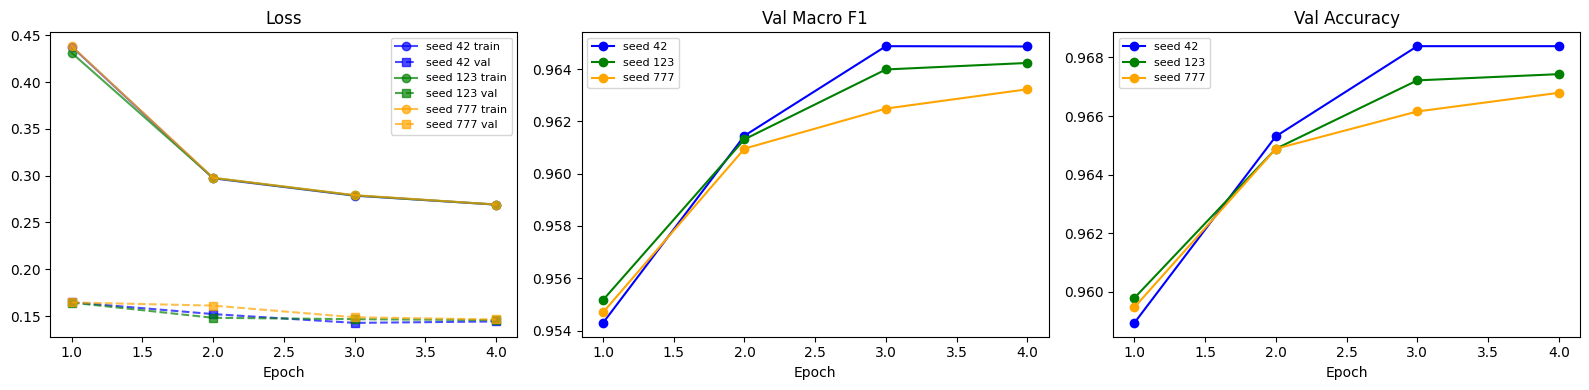

Saved: learning_curves.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ["blue", "green", "orange"]
for i, (history, seed) in enumerate(zip(all_histories, seeds_to_run)):
    epochs_ran = list(range(1, len(history["train_loss"]) + 1))
    c = colors[i % len(colors)]
    axes[0].plot(epochs_ran, history["train_loss"], "o-",  color=c, alpha=0.7, label=f"seed {seed} train")
    axes[0].plot(epochs_ran, history["val_loss"],   "s--", color=c, alpha=0.7, label=f"seed {seed} val")
    axes[1].plot(epochs_ran, history["val_f1"],     "o-",  color=c, label=f"seed {seed}")
    axes[2].plot(epochs_ran, history["val_acc"],    "o-",  color=c, label=f"seed {seed}")
axes[0].set_title("Loss");         axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Val Macro F1"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
axes[2].set_title("Val Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"), dpi=150)
plt.show()
print("Saved: learning_curves.png")

## Step 14 - Test set evaluation

Skipped if `HAS_TEST_SET=False`.

**To run later:** set `HAS_TEST_SET=True` in Step 3 and re-run Steps 4, 5, and 14.

In [ ]:
# ── Define both ensembles ─────────────────────────────────────
v2_ema_paths = [
    "deberta_single_evidence_v2/adapter_seed_42",
    "deberta_single_evidence_v2/adapter_seed_123",
    "deberta_single_evidence_v2/adapter_seed_777",
]

v3_ema_paths = [
    "deberta_single_evidence_v3/adapter_seed_42_ema",
    "deberta_single_evidence_v3/adapter_seed_123_ema",
    "deberta_single_evidence_v3/adapter_seed_777_ema",
]

In [ ]:
if not HAS_TEST_SET or test_loader is None:
    print("Test evaluation skipped — set HAS_TEST_SET=True in Step 3 when ready.")
else:
    @torch.no_grad()
    def ensemble_predict_loader(adapter_paths, loader):
        all_model_logits = []
        all_labels       = None
        for path in adapter_paths:
            print(f"  Loading: {path}")
            base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)
            m    = PeftModel.from_pretrained(base, path).to(DEVICE)
            m.eval()
            model_logits, batch_labels = [], []
            for batch in loader:
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels         = batch["labels"]
                token_type_ids = batch.get("token_type_ids")
                kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
                if token_type_ids is not None:
                    kwargs["token_type_ids"] = token_type_ids.to(DEVICE)
                model_logits.append(m(**kwargs).logits.cpu())
                batch_labels.append(labels)
            all_model_logits.append(torch.cat(model_logits, dim=0))
            if all_labels is None:
                all_labels = torch.cat(batch_labels, dim=0)
            del m, base
            torch.cuda.empty_cache()
        avg_logits = torch.stack(all_model_logits, dim=0).mean(dim=0)
        return torch.argmax(avg_logits, dim=-1).numpy(), all_labels.numpy()

    # ── v2 ───────────────────────────────────────────────────────
print("="*60 + "\nv2 EMA Ensemble\n" + "="*60)
v2_preds, v2_labels = ensemble_predict_loader(v2_ema_paths, test_loader)
label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]
v2_f1  = f1_score(v2_labels, v2_preds, average="macro")
v2_acc = accuracy_score(v2_labels, v2_preds)
print(f"Macro F1 : {v2_f1:.4f}  |  Accuracy : {v2_acc:.4f}")
print(classification_report(v2_labels, v2_preds, target_names=label_names, digits=4))

# ── v3 ───────────────────────────────────────────────────────
print("="*60 + "\nv3 EMA Ensemble\n" + "="*60)
v3_preds, v3_labels = ensemble_predict_loader(v3_ema_paths, test_loader)
v3_f1  = f1_score(v3_labels, v3_preds, average="macro")
v3_acc = accuracy_score(v3_labels, v3_preds)
print(f"Macro F1 : {v3_f1:.4f}  |  Accuracy : {v3_acc:.4f}")
print(classification_report(v3_labels, v3_preds, target_names=label_names, digits=4))

# ── Summary ──────────────────────────────────────────────────
print("="*60)
print(f"{'MODEL':<12} {'Macro F1':>10} {'Accuracy':>10}")
print("-"*60)
print(f"{'v2 EMA':<12} {v2_f1:>10.4f} {v2_acc:>10.4f}")
print(f"{'v3 EMA':<12} {v3_f1:>10.4f} {v3_acc:>10.4f}")
winner = "v3" if v3_f1 >= v2_f1 else "v2"
print(f"\nWinner: {winner}  (ΔF1 = {abs(v3_f1 - v2_f1):.4f})")
print("="*60)

# keep test_preds/test_labels pointing to the winner for Step 15 & 16
test_preds, test_labels = (v3_preds, v3_labels) if v3_f1 >= v2_f1 else (v2_preds, v2_labels)
test_f1, test_acc = (v3_f1, v3_acc) if v3_f1 >= v2_f1 else (v2_f1, v2_acc)

Test evaluation skipped — set HAS_TEST_SET=True in Step 3 when ready.


## Step 15 - Confusion matrix (skipped if no test set)

In [18]:
if not HAS_TEST_SET or test_loader is None:
    print("Confusion matrix skipped — no test set loaded.")
else:
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title("Confusion Matrix — Ensemble Test Set", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
    plt.show()

Confusion matrix skipped — no test set loaded.


## Step 16 - Save metrics

In [19]:
metrics = {
    "ensemble_seeds": seeds_to_run,
    "adapter_paths":  adapter_paths,
    "has_test_set":   HAS_TEST_SET,
    "config": {
        "lora_r":        LORA_R,
        "lora_alpha":    LORA_ALPHA,
        "max_len":       MAX_LEN,
        "rdrop_alpha":   RDROP_ALPHA,
        "fgm_epsilon":   FGM_EPSILON,
        "ema_decay":     EMA_DECAY,
        "warmup_ratio":  WARMUP_RATIO,
        "label_smooth":  LABEL_SMOOTHING,
    }
}
if HAS_TEST_SET and test_loader is not None:
    metrics["test_macro_f1"] = round(test_f1,  4)
    metrics["test_accuracy"] = round(test_acc, 4)

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved.")
if HAS_TEST_SET and test_loader is not None:
    print(f"Test macro F1 : {test_f1:.4f}  |  Test accuracy : {test_acc:.4f}")
else:
    print("Test results not yet available.")

Metrics saved.
Test results not yet available.


## Step 17 - Load models for inference

In [20]:
loaded_models = []
for path in adapter_paths:
    base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)
    m    = PeftModel.from_pretrained(base, path).to(DEVICE)
    m.eval()
    loaded_models.append(m)
print(f"{len(loaded_models)} models loaded for inference.")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task

3 models loaded for inference.


## Step 18 - Predict function

Takes one claim and one evidence string — matching the single-evidence training format.

In [21]:
@torch.no_grad()
def predict(claim: str, evidence: str) -> dict:
    """
    Classify a (claim, evidence) pair using the ensemble.

    Parameters
    ----------
    claim    : str  — atomic claim from ClaimExtractor
    evidence : str  — single evidence sentence from RAG

    Returns
    -------
    dict:
        label      : 'SUPPORTS' | 'REFUTES' | 'NOT ENOUGH INFO'
        confidence : float
        scores     : dict of all 3 label probabilities
    """
    encoding = tokenizer(
        claim.strip(),
        evidence.strip(),
        max_length=MAX_LEN,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

    all_logits = [m(**encoding).logits for m in loaded_models]
    avg_logits = torch.stack(all_logits, dim=0).mean(dim=0)
    probs      = torch.softmax(avg_logits, dim=-1).squeeze().cpu().numpy()
    pred_id    = int(np.argmax(probs))

    return {
        "label":      ID2LABEL[pred_id],
        "confidence": round(float(probs[pred_id]), 4),
        "scores":     {ID2LABEL[i]: round(float(probs[i]), 4) for i in range(NUM_LABELS)},
    }


# Demo
demo_pairs = [
    {"claim": "The Eiffel Tower is located in Berlin.",        "evidence": "The Eiffel Tower is on the Champ de Mars in Paris, France."},
    {"claim": "Marie Curie won the Nobel Prize in Physics.",   "evidence": "Marie Curie was awarded the Nobel Prize in Physics in 1903."},
    {"claim": "Python was first released in 2022.",            "evidence": "The population of insects on Earth exceeds one quintillion."},
]
print("Demo predictions:")
print("-" * 60)
for pair in demo_pairs:
    result = predict(pair["claim"], pair["evidence"])
    print(f"CLAIM      : {pair['claim']}")
    print(f"EVIDENCE   : {pair['evidence']}")
    print(f"PREDICTION : {result['label']}  ({result['confidence']:.2%})")
    print(f"SCORES     : {result['scores']}")
    print("-" * 60)

Demo predictions:
------------------------------------------------------------
CLAIM      : The Eiffel Tower is located in Berlin.
EVIDENCE   : The Eiffel Tower is on the Champ de Mars in Paris, France.
PREDICTION : REFUTES  (97.80%)
SCORES     : {'SUPPORTS': 0.0044, 'REFUTES': 0.978, 'NOT ENOUGH INFO': 0.0176}
------------------------------------------------------------
CLAIM      : Marie Curie won the Nobel Prize in Physics.
EVIDENCE   : Marie Curie was awarded the Nobel Prize in Physics in 1903.
PREDICTION : SUPPORTS  (91.70%)
SCORES     : {'SUPPORTS': 0.917, 'REFUTES': 0.0361, 'NOT ENOUGH INFO': 0.0468}
------------------------------------------------------------
CLAIM      : Python was first released in 2022.
EVIDENCE   : The population of insects on Earth exceeds one quintillion.
PREDICTION : NOT ENOUGH INFO  (87.37%)
SCORES     : {'SUPPORTS': 0.0058, 'REFUTES': 0.1205, 'NOT ENOUGH INFO': 0.8737}
------------------------------------------------------------


In [22]:
# Check what's actually inside the saved adapter folder
import os

path = "deberta_single_evidence/adapter_seed_42"
print("Adapter folder contents:")
for f in os.listdir(path):
    size = os.path.getsize(os.path.join(path, f))
    print(f"  {f}  ({size/1e6:.2f} MB)")

Adapter folder contents:
  spm.model  (2.46 MB)
  README.md  (0.01 MB)
  added_tokens.json  (0.00 MB)
  tokenizer_config.json  (0.00 MB)
  special_tokens_map.json  (0.00 MB)
  adapter_model.safetensors  (6.32 MB)
  tokenizer.json  (8.66 MB)
  adapter_config.json  (0.00 MB)


## Step 19 - Full pipeline integration

import sys
sys.path.append(".")
from claim_extractor import ClaimExtractor

extractor = ClaimExtractor(use_llm=True, llm_provider="ollama", llm_model="llama3.1:8b")


def get_evidence_for_claim(claim: str) -> str:
    """
    Returns a SINGLE evidence string for the claim.
    Replace with your actual RAG Wikipedia retrieval.
    Should return the single most relevant Wikipedia sentence.
    """
    return "[RAG retrieval not yet implemented — plug in Wikipedia search here]"


def analyze_paragraph(paragraph: str, verbose: bool = False) -> list:
    """
    Full hallucination detection pipeline.

    Steps:
        1. Extract atomic claims from paragraph using ClaimExtractor
        2. For each claim retrieve one evidence sentence from Wikipedia (RAG)
        3. Pass (claim, evidence) to DeBERTa ensemble
        4. Return label + confidence for each claim

    Returns list of dicts, one per claim:
        { claim, evidence, label, confidence, scores }
    """
    claims = extractor.extract(paragraph, verbose=verbose)
    print(f"Extracted {len(claims)} claims")

    results = []
    for i, claim in enumerate(claims, 1):
        evidence   = get_evidence_for_claim(claim)
        prediction = predict(claim, evidence)

        results.append({
            "claim":      claim,
            "evidence":   evidence,
            "label":      prediction["label"],
            "confidence": prediction["confidence"],
            "scores":     prediction["scores"],
        })

        status = {"SUPPORTS": "✓", "REFUTES": "✗", "NOT ENOUGH INFO": "?"}[prediction["label"]]
        print(f"  {status} [{prediction['confidence']:.0%}] {claim}")
        print(f"      ev: {evidence[:80]}")

    return results


# Test
test = """
Marie Curie was born in Warsaw in 1867. She won the Nobel Prize in
Physics in 1903 and the Chemistry prize in 1911. She studied at
Harvard University and was born in 1920.
"""
results = analyze_paragraph(test)

---

## How to add the test set later
1. Set `HAS_TEST_SET = True` in Step 3
2. Re-run Steps 4, 5, 14, 15, 16
   (the test split is already created in Step 4 from the same dataset)

## How to reload the ensemble after training
```python
from transformers import AutoModelForSequenceClassification
from peft import PeftModel

loaded_models = []
for path in ["deberta_single_evidence/adapter_seed_42",
             "deberta_single_evidence/adapter_seed_123",
             "deberta_single_evidence/adapter_seed_777"]:
    base = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-v3-large', num_labels=3)
    m    = PeftModel.from_pretrained(base, path).to(device)
    m.eval()
    loaded_models.append(m)
```

## Expected performance
| Configuration | Expected Macro F1 |
|---|---|
| Basic LoRA only | ~0.83-0.85 |
| + R-Drop + FGM | ~0.86-0.88 |
| + EMA | ~0.87-0.89 |
| + Ensemble (3 seeds) | ~0.88-0.91 |

Note: single evidence is slightly lower than multi-evidence because
the model sees less context per claim. This is the expected tradeoff.